# 薬学インフォマティクス第5回 <ゲノム配列解析> No. 0

2026.05.07 Kawaguchi RK.

* 内容： pytorchの基本
* 目標： pytorchでのニューラルネットワーク学習の流れを理解する
* リンク： https://github.com/carushi/cb_lab/tree/main/code_collection/2026_pharmacoinformatics/No5

## 参考図書
* Pytorch 自然言語処理プログラミング (新納浩幸)

## Google colab用コード

In [ ]:
!pip install torch pandas seaborn tqdm matplotlib

## Import packages

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

## Preapre the datasets
* iris dataset
* predict iris type (setosa, versicolor, and vernicia)

In [19]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = datasets.load_iris()
print(iris.DESCR)
print(iris.data.shape)
print(iris.target)
xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, test_size=0.5)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
xtrain = torch.from_numpy(xtrain).type('torch.FloatTensor')
ytrain = torch.from_numpy(ytrain).type('torch.LongTensor')
xtest = torch.from_numpy(xtest).type('torch.FloatTensor')
ytest = torch.from_numpy(ytest).type('torch.LongTensor')

## Model

In [6]:
class MyIris(nn.Module):
    def __init__(self):
        super(MyIris, self).__init__()
        self.l1 = nn.Linear(4,6)
        self.l2 = nn.Linear(6,6)
        self.l3 = nn.Linear(6,3)

    def forward(self, x):
        h1 = torch.sigmoid(self.l1(x))
        h2 = self.l2(h1)
        h3 = self.l3(h2)
        return h3


## Training setting

In [7]:
model = MyIris()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [8]:
criterion = nn.CrossEntropyLoss()

## Training process

In [9]:
%%time
model.train()
# TODO: lossを保存するリスト・アレイを定義
for i in range(1000):
    output = model(xtrain)
    loss = criterion(output, ytrain)
    if i%50 == 0:
        print('iter:', i, '->', loss.item())
    # TODO: lossを保存する
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

iter: 0 -> 1.1235637664794922
iter: 50 -> 1.0484699010849
iter: 100 -> 0.8160454034805298
iter: 150 -> 0.5303184390068054
iter: 200 -> 0.4234868288040161
iter: 250 -> 0.32556337118148804
iter: 300 -> 0.24186357855796814
iter: 350 -> 0.24874740839004517
iter: 400 -> 0.22072753310203552
iter: 450 -> 0.19464288651943207
iter: 500 -> 0.16802234947681427
iter: 550 -> 0.14115120470523834
iter: 600 -> 0.11996439844369888
iter: 650 -> 0.11027820408344269
iter: 700 -> 0.10168647021055222
iter: 750 -> 0.09681005775928497
iter: 800 -> 0.09588105231523514
iter: 850 -> 0.0913272351026535
iter: 900 -> 0.089411161839962
iter: 950 -> 0.08872758597135544
CPU times: user 138 ms, sys: 32 ms, total: 170 ms
Wall time: 179 ms


In [10]:
torch.save(model.state_dict(), 'myiris.model')
model.load_state_dict(torch.load('myiris.model'))

<All keys matched successfully>

## Output

In [11]:
model.eval()
# no grad is required to compute the test dataset without optimization
with torch.no_grad():
    output1 = model(xtest)
    ans = torch.argmax(output1, 1) # 0, 1, 2 for each
    accuracy_all = ((ytest == ans).sum().float() / len(ans)).item()
    print(accuracy_all)

0.9599999785423279


In [ ]:
# TODO: 可視化コード
# ヒント: 訓練ロスをグラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する
import matplotlib.pyplot as plt

plt.plot(???(x-axis value), ???(y-axis value), label="train")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

## Batch computation

In [12]:
%%time
model = MyIris()
n = 75 # data size
bs = 25 # batch size
model.train()
# TODO: lossを保存するリスト・アレイを定義
for i in range(1000):
    idx = np.random.permutation(n)
    for j in range(0, n, bs):
        xtm = xtrain[idx[j:min(j+bs, n)]]
        ytm = ytrain[idx[j:min(j+bs, n)]]
        output = model(xtm)
        loss = criterion(output, ytm)
        if i%50 == 0:
            print('iter:', i, 'batch:', j, '->', loss.item())
        # TODO: loss.item()を保存する
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

iter: 0 batch: 0 -> 1.095847249031067
iter: 0 batch: 25 -> 1.0889549255371094
iter: 0 batch: 50 -> 1.0932024717330933
iter: 50 batch: 0 -> 1.092556118965149
iter: 50 batch: 25 -> 1.0895764827728271
iter: 50 batch: 50 -> 1.095871925354004
iter: 100 batch: 0 -> 1.0941472053527832
iter: 100 batch: 25 -> 1.0887962579727173
iter: 100 batch: 50 -> 1.0950610637664795
iter: 150 batch: 0 -> 1.0971553325653076
iter: 150 batch: 25 -> 1.0835769176483154
iter: 150 batch: 50 -> 1.097272276878357
iter: 200 batch: 0 -> 1.1041563749313354
iter: 200 batch: 25 -> 1.1025612354278564
iter: 200 batch: 50 -> 1.071286916732788
iter: 250 batch: 0 -> 1.0875632762908936
iter: 250 batch: 25 -> 1.090889573097229
iter: 250 batch: 50 -> 1.0995515584945679
iter: 300 batch: 0 -> 1.0997337102890015
iter: 300 batch: 25 -> 1.0865826606750488
iter: 300 batch: 50 -> 1.0916880369186401
iter: 350 batch: 0 -> 1.0810548067092896
iter: 350 batch: 25 -> 1.0929512977600098
iter: 350 batch: 50 -> 1.1039983034133911
iter: 400 batch

In [13]:
model.eval()
# no grad is required to compute the test dataset without optimization
with torch.no_grad():
    output1 = model(xtest)
    ans = torch.argmax(output1, 1) # 0, 1, 2 for each
    accuracy_batch = ((ytest == ans).sum().float() / len(ans)).item()
    print(accuracy_batch)

0.3466666638851166


In [ ]:
# TODO: 可視化コード
# ヒント: 訓練ロスをグラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する

## GPU-based computation
* Move tonsor arrays to GPU
* Move the model to GPU

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available()
                      else "cpu")

In [ ]:
print(torch.cuda.is_available()) # TrueならGPU利用可能、次へ
print(torch.backends.mps.is_available()) # For mac

True

## Edit the code for GPU utilization
* device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
* xtrain = xtrain.to(device)
* ytrain = ytrain.to(device)
* xtest = xtest.to(device)
* ytest = ytest.to(device)
* model = MyIris().to(device)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
xtrain = xtrain.to(device)
ytrain = ytrain.to(device)
xtest = xtest.to(device)
ytest = ytest.to(device)
model = MyIris().to(device)

In [ ]:
%%time
n = 75 # data size
bs = 25 # batch size
model.train()
# TODO: lossを保存するリスト・アレイを定義
for i in range(1000):
    idx = np.random.permutation(n)
    for j in range(0, n, bs):
        xtm = xtrain[idx[j:min(j+bs, n)]]
        ytm = ytrain[idx[j:min(j+bs, n)]]
        output = model(xtm)
        loss = criterion(output, ytm)
        if i%50 == 0:
            print('iter:', i, 'batch:', j, '->', loss.item())
        # TODO: loss.item()を保存する        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

iter: 0 batch: 0 -> 1.1306591033935547
iter: 0 batch: 25 -> 1.2041831016540527
iter: 0 batch: 50 -> 1.1038541793823242
iter: 50 batch: 0 -> 1.1528750658035278
iter: 50 batch: 25 -> 1.1343859434127808
iter: 50 batch: 50 -> 1.151435375213623
iter: 100 batch: 0 -> 1.1538130044937134
iter: 100 batch: 25 -> 1.2435146570205688
iter: 100 batch: 50 -> 1.0413686037063599
iter: 150 batch: 0 -> 1.1213586330413818
iter: 150 batch: 25 -> 1.1516942977905273
iter: 150 batch: 50 -> 1.165643334388733
iter: 200 batch: 0 -> 1.1607247591018677
iter: 200 batch: 25 -> 1.1205402612686157
iter: 200 batch: 50 -> 1.1574311256408691
iter: 250 batch: 0 -> 1.1404441595077515
iter: 250 batch: 25 -> 1.0909641981124878
iter: 250 batch: 50 -> 1.2072879076004028
iter: 300 batch: 0 -> 1.1263096332550049
iter: 300 batch: 25 -> 1.2033919095993042
iter: 300 batch: 50 -> 1.108994722366333
iter: 350 batch: 0 -> 1.1004481315612793
iter: 350 batch: 25 -> 1.1555511951446533
iter: 350 batch: 50 -> 1.1826969385147095
iter: 400 ba

In [17]:
model.eval()
# no grad is required to compute the test dataset without optimization
with torch.no_grad():
    output1 = model(xtest)
    ans = torch.argmax(output1, 1) # 0, 1, 2 for each
    accuracy_gpu = ((ytest == ans).sum().float() / len(ans)).item()
    print(accuracy_gpu)

0.3333333432674408


In [ ]:
# TODO: 可視化コード
# ヒント: 訓練ロスをグラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する

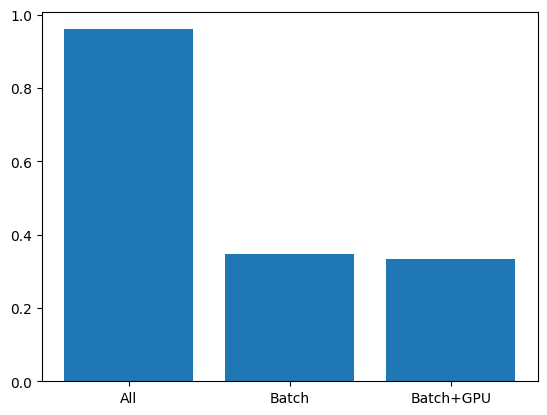

In [ ]:
# TODO: 可視化コード（おまけ、必須では有りません）
# ヒント: accuracy_all, accuracy_batch, accuracy_gpuを棒グラフにする
#        以下のような関数を使う
#        この可視化コードをそれぞれの訓練のセルの下に挿入する
plt.bar([0, 1, 2], [???, ???, ???], tick_label=['All', 'Batch', 'Batch+GPU'])
plt.show()
